# llama3.3:70b — results

How well **llama3.3:70b** labels DMP documents, using **pdfplumber** to read the PDFs.

All 10 sample documents are scored.


## Setup


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dmpbridge.core import paths
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    extract_gold, _match_structured, _confusion_from_match,
    micro_prf1, compute_f1_rows, resolve_old_gt_path,
)
from dmpbridge.evaluation.annotation_rules import convert_tag_to_final, load_method_new

MODEL = 'llama3.3:70b'
TAG   = 'llama3.3-70b_pdfplumber_whole_doc'
BLUE, GREEN = '#1d4ed8', '#059669'

df_a, conf_a, err_a = load_method_old(TAG, exclude=[])
if df_a is None:
    raise FileNotFoundError(
        f'No output for {TAG}. Run:\n'
        f'  dmpbridge-wholedoc --model {MODEL} --extractor pdfplumber --start 1 --end 10')
convert_tag_to_final(TAG)
df_b, conf_b, err_b = load_method_new(TAG, exclude=[])

print(f'{MODEL} + pdfplumber — {len(df_a)} documents loaded')


llama3.3:70b + pdfplumber — 10 documents loaded


## 1 — How the score is worked out

Worth reading first, because the numbers later on only make sense once this is clear.

Two lists are compared. One is **your annotation** — the correct answer. The other is
**what the model produced**. Every item in both lists is a piece of text plus the label
it was given.

The example below uses one document. Change `SAMPLE` to look at a different one.


In [2]:
SAMPLE = 1        # <-- change to inspect another document

reference = extract_gold(resolve_old_gt_path(SAMPLE))
produced  = extract_gold(paths.structured_path(TAG, SAMPLE))

print(f'sample{SAMPLE}')
print(f'  your annotation says there are {len(reference)} items')
print(f'  the model produced             {len(produced)} items')
print()
print('YOUR ANNOTATION (the correct answer)')
print('-' * 92)
for i, (text, label) in enumerate(reference, 1):
    tail = '...' if len(text) > 60 else ''
    print(f'{i:>3}  {label:<22}{text[:60]}{tail}')


sample1
  your annotation says there are 28 items
  the model produced             29 items

YOUR ANNOTATION (the correct answer)
--------------------------------------------------------------------------------------------
  1  title                 DATA MANAGEMENT AND SHARING PLAN
  2  section.title         Element 1: Data Type:
  3  question.text         A. Types and amount of scientific data expected to be genera...
  4  answer.text           This secondary data analysis project will analyze deidentifi...
  5  question.text         B. Scientific data that will be preserved and shared, and th...
  6  answer.text           As this is a secondary data analysis project, we will only b...
  7  question.text         C. Metadata, other relevant data, and associated documentati...
  8  answer.text           In addition to the data described above, code and models wil...
  9  section.title         Element 2: Related Tools, Software and/or Code:
 10  answer.text           Data will be analyze

### Pairing the two lists

Each item in your annotation looks for itself in the model's list, matching on the words
they share. Four things can happen:

| | |
|---|---|
| **correct** | the model found it and gave it the right label |
| **wrong label** | it found the text but called it something else |
| **missed** | the model produced nothing matching it |
| **extra** | the model produced something that isn't in your annotation at all |


In [3]:
records, extras = _match_structured(paths.structured_path(TAG, SAMPLE), reference)

correct = [r for r in records if r['pred_label'] == r['gold_label']]
wrong   = [r for r in records if r['pred_label'] and r['pred_label'] != r['gold_label']]
missed  = [r for r in records if r['pred_label'] is None]

print(f'  correct       {len(correct):>3}')
print(f'  wrong label   {len(wrong):>3}')
print(f'  missed        {len(missed):>3}')
print('  ' + '-' * 17)
print(f'  your annotation {len(reference):>1}')
print()
print(f'  extra         {len(extras):>3}   (produced, but not in your annotation)')

for name, group in (('WRONG LABEL', wrong), ('MISSED', missed)):
    if group:
        print()
        print(name)
        for r in group:
            called = r['pred_label'] or 'nothing'
            print(f"  called {called:<20} should be {r['gold_label']:<20}"
                  f"{r['gold_text'][:40]!r}")
if extras:
    print()
    print('EXTRA')
    for text, label in extras:
        print(f'  {label:<22}{text[:52]!r}')


  correct        26
  wrong label     2
  missed          0
  -----------------
  your annotation 28

  extra           1   (produced, but not in your annotation)

WRONG LABEL
  called section.description  should be answer.text         'The following data will be created as a '
  called section.title        should be question.text       'Protections for privacy, rights, and con'

EXTRA
  answer.text           'Objective sedentary behavior metrics – no existing s'


### From counts to a score

**Precision** — of everything the model produced, how much was right?

**Recall** — of everything in your annotation, how much did it find?

**F1** — both combined into one number. It stays low unless *both* are high, so a model
cannot look good by producing very little, or by producing everything it can think of.


In [4]:
n_correct  = len(correct)
n_produced = len(correct) + len(wrong) + len(extras)

precision = n_correct / n_produced
recall    = n_correct / len(reference)
f1        = 2 * precision * recall / (precision + recall)

print(f'  precision = {n_correct} right / {n_produced} produced      = {precision*100:.1f}%')
print(f'  recall    = {n_correct} right / {len(reference)} in your list  = {recall*100:.1f}%')
print(f'  F1                                     = {f1*100:.1f}%')

# Guard: if this ever disagreed with the real scoring code, the cell should fail
# rather than quietly show a wrong explanation.
lib = micro_prf1(_confusion_from_match(records, extras))
assert abs(lib['f1'] - f1) < 1e-9


  precision = 26 right / 29 produced      = 89.7%
  recall    = 26 right / 28 in your list  = 92.9%
  F1                                     = 91.2%


> **One catch.** A wrong label costs twice — your item counts as not found, *and* the
> model's version counts as something it shouldn't have produced. That is why a handful
> of wrong labels moves the score a long way.

> **If you count mistakes by hand you will get a different number**, and that is fine.
> Scoring happens after neighbouring lines with the same label are glued together, so
> five mislabelled lines of one paragraph become a single mistake — while five
> mislabelled headings stay five separate mistakes.


## 2 — The score

Across all 10 documents.

**Path A** compares the model's output against your original annotation.
**Path B** first fills in blank questions using the rules in `Rules.xlsx`, then compares
against your newer annotation.


In [5]:
rows = []
for path, conf in (('A', conf_a), ('B', conf_b)):
    m = micro_prf1(conf)
    rows.append({'path': path, 'precision': m['precision'] * 100,
                 'recall': m['recall'] * 100, 'f1': m['f1'] * 100,
                 'right': m['tp'], 'extra': m['fp'], 'missed': m['fn']})
summary = pd.DataFrame(rows).set_index('path')

print(f'{MODEL} + pdfplumber   ·   all 10 documents')
print()
print(f"{'':<9}{'Precision':>11}{'Recall':>9}{'F1':>9}{'right':>8}{'extra':>7}{'missed':>8}")
print('-' * 62)
for p, r in summary.iterrows():
    print(f"{'Path ' + p:<9}{r['precision']:>10.1f}%{r['recall']:>8.1f}%{r['f1']:>8.1f}%"
          f"{r['right']:>8.0f}{r['extra']:>7.0f}{r['missed']:>8.0f}")


llama3.3:70b + pdfplumber   ·   all 10 documents

           Precision   Recall       F1   right  extra  missed
--------------------------------------------------------------
Path A         81.0%    83.2%    82.1%     119     28      24
Path B         72.0%    80.6%    76.1%     108     42      26


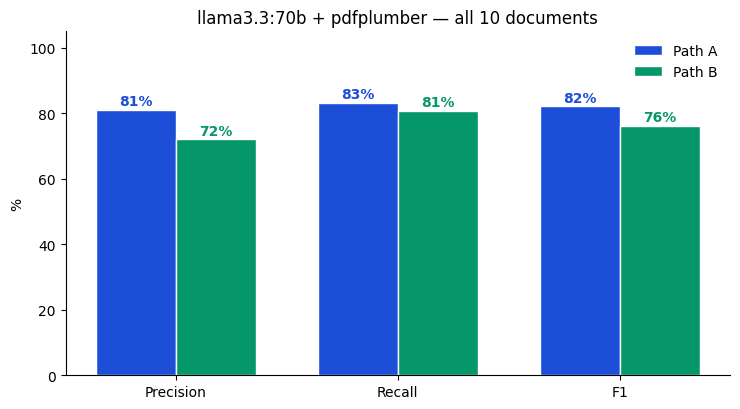

In [6]:
metrics = ['precision', 'recall', 'f1']
w = 0.36

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, (path, color) in enumerate(zip(('A', 'B'), (BLUE, GREEN))):
    vals = [summary.loc[path, m] for m in metrics]
    bars = ax.bar([x + (i - 0.5) * w for x in range(3)], vals, width=w,
                  label=f'Path {path}', color=color, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f'{v:.0f}%',
                ha='center', fontsize=10, fontweight='bold', color=color)
ax.set_xticks(range(3))
ax.set_xticklabels(['Precision', 'Recall', 'F1'])
ax.set_ylim(0, 105)
ax.set_ylabel('%')
ax.set_title(f'{MODEL} + pdfplumber — all 10 documents')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


## 3 — Which labels it handles well

`items` is how many of each label exist in your annotation. Where that number is small,
the score jumps around a lot — one document can move it by tens of points.


label                       Path A    Path B    items
-----------------------------------------------------
title                        90.0%     90.0%       10
section.title                79.1%     79.1%       43
section.description          53.3%     53.3%        8
question.text                63.6%     51.2%       22
answer.text                  93.3%     83.5%       60


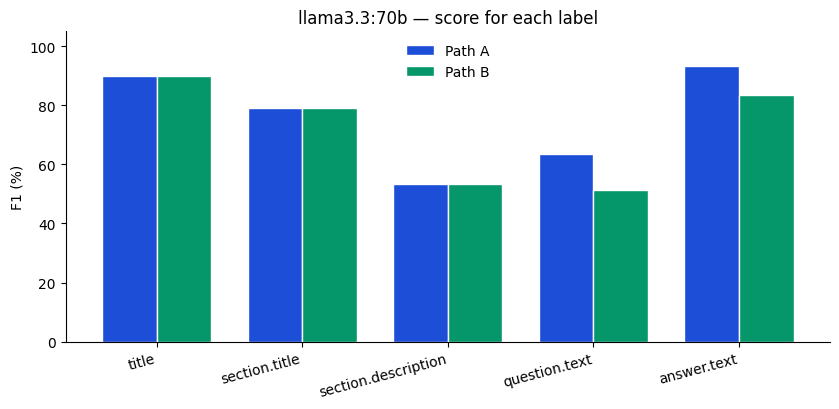

In [7]:
fa = compute_f1_rows(conf_a).set_index('label')
fb = compute_f1_rows(conf_b).set_index('label')
per_label = pd.DataFrame({'Path A': fa['f1'] * 100, 'Path B': fb['f1'] * 100})

print(f"{'label':<24}{'Path A':>10}{'Path B':>10}{'items':>9}")
print('-' * 53)
for lab, row in per_label.iterrows():
    print(f"{lab:<24}{row['Path A']:>9.1f}%{row['Path B']:>9.1f}%{fa.loc[lab, 'support']:>9}")

ax = per_label.plot(kind='bar', figsize=(8.5, 4.2), width=0.75,
                    color=[BLUE, GREEN], edgecolor='white')
ax.set_ylabel('F1 (%)')
ax.set_xlabel('')
ax.set_ylim(0, 105)
ax.set_title(f'{MODEL} — score for each label')
ax.legend(frameon=False)
plt.xticks(rotation=15, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


## 4 — Which documents it handles well

Red is below 50%, green is 80% or above.


document     right  total    score
----------------------------------
sample1         26     28    92.9%
sample2         14     25    56.0%
sample3         12     14    85.7%
sample4          3      3   100.0%
sample5          9     13    69.2%
sample6          6     11    54.5%
sample7          3      3   100.0%
sample8         13     13   100.0%
sample9          9     11    81.8%
sample10        13     13   100.0%
----------------------------------
TOTAL          108    134    80.6%


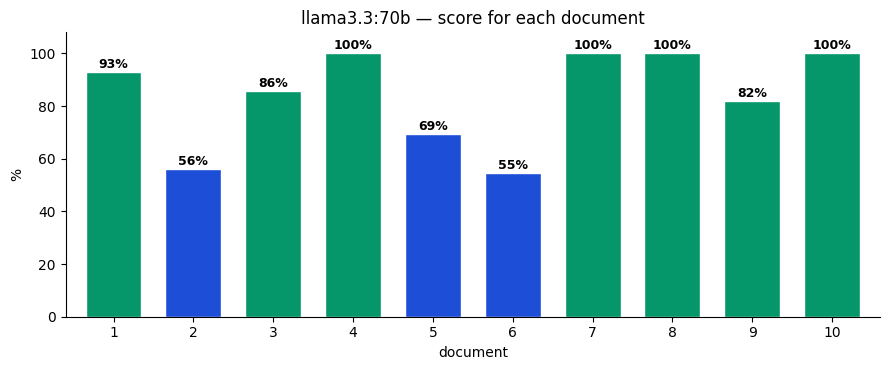

In [8]:
ps = df_b.set_index('sample').copy()
ps.index = [s.replace('sample', '') for s in ps.index]
ps = ps.loc[sorted(ps.index, key=int)]

print(f"{'document':<11}{'right':>7}{'total':>7}{'score':>9}")
print('-' * 34)
for s, r in ps.iterrows():
    print(f"{'sample' + s:<11}{r['correct']:>7.0f}{r['total']:>7.0f}{r['accuracy'] * 100:>8.1f}%")
print('-' * 34)
print(f"{'TOTAL':<11}{ps['correct'].sum():>7.0f}{ps['total'].sum():>7.0f}"
      f"{ps['correct'].sum() / ps['total'].sum() * 100:>8.1f}%")

colors = ['#dc2626' if v < 0.5 else GREEN if v >= 0.8 else BLUE for v in ps['accuracy']]
ax = (ps['accuracy'] * 100).plot(kind='bar', figsize=(9, 3.8), color=colors,
                                 width=0.7, edgecolor='white')
for i, v in enumerate(ps['accuracy'] * 100):
    ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('%')
ax.set_xlabel('document')
ax.set_ylim(0, 108)
ax.set_title(f'{MODEL} — score for each document')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()


## 5 — What it gets wrong

The most common mistakes across all 10 documents, with examples.


In [9]:
counts = err_b.groupby(['true', 'pred']).size().sort_values(ascending=False)

print(f'{len(err_b)} mistakes in total')
print()
print(f"{'should have been':<24}{'was called':<24}{'times':>6}")
print('-' * 54)
for (t, p), c in counts.head(8).items():
    label = 'nothing (extra)' if t == 'no_gold_match' else t
    print(f'{label:<24}{p:<24}{c:>6}')

print()
print('examples:')
for _, e in err_b.head(6).iterrows():
    label = 'extra' if e['true'] == 'no_gold_match' else f"{e['true']} -> {e['pred']}"
    print(f"  [{e['sample']}]  {label}")
    print(f"      {e['text'][:88]!r}")


42 mistakes in total

should have been        was called               times
------------------------------------------------------
nothing (extra)         answer.text                 12
nothing (extra)         question.text                7
nothing (extra)         section.title                6
question.text           section.title                4
section.description     question.text                4
answer.text             question.text                3
answer.text             section.description          2
answer.text             section.title                2

examples:
  [sample1]  answer.text -> section.description
      'The following data will be created as a result of this project:'
  [sample1]  question.text -> section.title
      'Protections for privacy, rights, and confidentiality of human research participants:'
  [sample1]  extra
      'Objective sedentary behavior metrics – no existing standards'
  [sample2]  question.text -> section.title
      'Content and Format. A

## Notes

- Running the same thing twice can change the score by about **3 points**, so small
  differences are not meaningful.
- Path A and Path B usually land close together. The rules mostly fill a question with
  its own section heading, and the scoring deliberately does not count the same text
  twice, so most of what they add is not counted as a separate item.
- To see how the annotation rules work, open `annotation_conversion_test.ipynb`.
